# Week 5 · Assessment — EDA Practical

## Setup Dataset

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

In [2]:

rng = np.random.default_rng(seed=7)
n = 4000

tickets = pd.DataFrame({
    "ticket_id": np.arange(1, n + 1),
    "created_at": pd.date_range("2024-03-01", periods=n, freq="30min"),
    "agent_id": rng.integers(200, 260, size=n),
    "priority": rng.choice(["Low", "Medium", "High", "high"], size=n),
    "resolution_hours": rng.gamma(shape=2.0, scale=6.0, size=n).round(2),
    "channel": rng.choice(["Email", "Chat", "Phone", None], size=n, p=[0.35, 0.35, 0.25, 0.05]),
})

tickets.loc[rng.choice(n, 120, replace=False), "agent_id"] = None
tickets.loc[rng.choice(n, 25, replace=False), "resolution_hours"] *= -1
tickets.loc[rng.choice(n, 15, replace=False), "resolution_hours"] = 999.0
tickets = pd.concat([tickets, tickets.sample(12, random_state=3)])


#### Self-check setup

In [3]:
assert tickets.shape == (4012, 6)
assert list(tickets.columns) == ["ticket_id", "created_at", "agent_id", "priority", "resolution_hours", "channel"]
print("Setup confirmed — dataset matches spec.")

Setup confirmed — dataset matches spec.


## 1. Diagnosis

In [4]:
tickets.head()

,ticket_id,created_at,agent_id,priority,resolution_hours,channel
0,1,2024-03-01 00:00:00,256.0,High,4.20,Email
1,2,2024-03-01 00:30:00,237.0,Low,13.49,Chat
2,3,2024-03-01 01:00:00,241.0,high,6.97,Email
3,4,2024-03-01 01:30:00,253.0,Medium,4.90,Chat
4,5,2024-03-01 02:00:00,234.0,Medium,5.60,Email


In [5]:
tickets.info()

<class 'pandas.DataFrame'>
Index: 4012 entries, 0 to 1707
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         4012 non-null   int64         
 1   created_at        4012 non-null   datetime64[us]
 2   agent_id          3891 non-null   float64       
 3   priority          4012 non-null   str           
 4   resolution_hours  4012 non-null   float64       
 5   channel           3819 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 219.4 KB


In [6]:
tickets.describe()

,ticket_id,created_at,agent_id,resolution_hours
count,4012.000000,4012,3891.000000,4012.000000
mean,2001.531406,2024-04-11 16:15:56.530408,229.814701,15.561725
min,1.000000,2024-03-01 00:00:00,200.000000,-37.810000
25%,1002.750000,2024-03-21 20:52:30,215.000000,5.700000
50%,2000.500000,2024-04-11 15:45:00,229.000000,10.180000
75%,3002.250000,2024-05-02 12:37:30,245.000000,16.242500
max,4000.000000,2024-05-23 07:30:00,259.000000,999.000000
std,1154.879052,NaN,17.141925,60.867741


In [7]:
print("Tickets — missing values")
tickets.isna().sum()

Tickets — missing values


ticket_id             0
created_at            0
agent_id            121
priority              0
resolution_hours      0
channel             193
dtype: int64

In [8]:
tickets["priority"].value_counts()

priority
Medium    1019
Low       1011
High      1000
high       982
Name: count, dtype: int64

In [9]:
tickets["channel"].value_counts(dropna=False)

channel
Chat     1411
Email    1382
Phone    1026
NaN       193
Name: count, dtype: int64

In [10]:
print("Exact duplicate rows:", tickets.duplicated().sum())
print("Negative resolution_hours:", (tickets["resolution_hours"] < 0).sum())
print("resolution_hours == 999.0:", (tickets["resolution_hours"] == 999.0).sum())
print(tickets["resolution_hours"].sort_values(ascending=False).head(20).values)

Exact duplicate rows: 12
Negative resolution_hours: 25
resolution_hours == 999.0: 15
[999.   999.   999.   999.   999.   999.   999.   999.   999.   999.
 999.   999.   999.   999.   999.    62.03  57.86  54.15  53.96  53.6 ]


**Problems found, before fixing anything:**

1. **`agent_id` has 121 missing values.** These show up as `NaN`, which also silently upcasts the column from what should be an integer ID to `float64`.
2. **`channel` has 193 missing values** (~4.8% of rows) — the intake source wasn't recorded for those tickets.
3. **`priority` has a hidden duplicate category:** `"High"` and `"high"` are being treated as two different values by `.value_counts()` (1000 vs 982), even though they mean the same thing. This isn't a missing-value problem — a plain `isna()` check would never catch it.
4. **12 exact duplicate rows** exist (same `ticket_id` and all). They came from tickets being concatenated onto themselves, not from two agents logging the same event.
5. **25 rows have negative `resolution_hours`.** A ticket cannot take negative time to resolve — this is a sign-flip type corruption, not a plausible real value.
6. **15 rows have `resolution_hours` exactly equal to 999.0**, far above the real maximum (~62h). The fact that it's the *exact same number* 15 times, not just "a big number," is the signature of a placeholder/sentinel value rather than a genuine slow resolution.

### Save Findings

In [11]:

findings = {
    "missing_agent_id": int(tickets["agent_id"].isna().sum()),
    "missing_channel": int(tickets["channel"].isna().sum()),
    "duplicate_rows": int(tickets.duplicated().sum()),
    "negative_resolution_hours": int((tickets["resolution_hours"] < 0).sum()),
    "outlier_resolution_hours": int((tickets["resolution_hours"] == 999.0).sum()),
}
with open("findings.json", "w") as f:
    json.dump(findings, f)

findings

{'missing_agent_id': 121,
 'missing_channel': 193,
 'duplicate_rows': 12,
 'negative_resolution_hours': 25,
 'outlier_resolution_hours': 15}

## 2. Cleaning
Working on a copy — `tickets` itself is left untouched below for inspection.

In [12]:
clean = tickets.copy()


#### duplicate rows 

In [13]:
clean = clean.drop_duplicates()

 #### "High" vs "high" -> normalize casing.

In [14]:
clean["priority"] = clean["priority"].str.lower()

#### Negative resolution_hours 

In [15]:
clean = clean[clean["resolution_hours"] >= 0]

#### resolution_hours == 999.0 -

In [16]:
count_999 = (clean["resolution_hours"] == 999.0).sum()
print("Number of 999.0 values:", count_999)

Number of 999.0 values: 15


In [17]:
median_resolution = clean.loc[clean["resolution_hours"] != 999.0,"resolution_hours"].median()
print(median_resolution)

10.21


In [18]:
clean.loc[clean["resolution_hours"] == 999.0,"resolution_hours"] = median_resolution

#### Missing channel -> fill with "Unknown".

In [19]:
clean["channel"] = clean["channel"].fillna("Unknown")

#### Missing agent_id -> drop rows

In [20]:
clean = clean.dropna(subset=["agent_id"])
clean["agent_id"] = clean["agent_id"].astype(int)

In [21]:
print("Cleaned shape:", clean.shape)
print("Original tickets still:", tickets.shape)  # unchanged, still inspectable
clean.head()

Cleaned shape: (3856, 6)
Original tickets still: (4012, 6)


,ticket_id,created_at,agent_id,priority,resolution_hours,channel
0,1,2024-03-01 00:00:00,256,high,4.20,Email
1,2,2024-03-01 00:30:00,237,low,13.49,Chat
2,3,2024-03-01 01:00:00,241,high,6.97,Email
3,4,2024-03-01 01:30:00,253,medium,4.90,Chat
4,5,2024-03-01 02:00:00,234,medium,5.60,Email


In [22]:
#### Saving the Clean Data

In [23]:
clean.to_csv("tickets_clean.csv", index=False)

## 3. Visualization

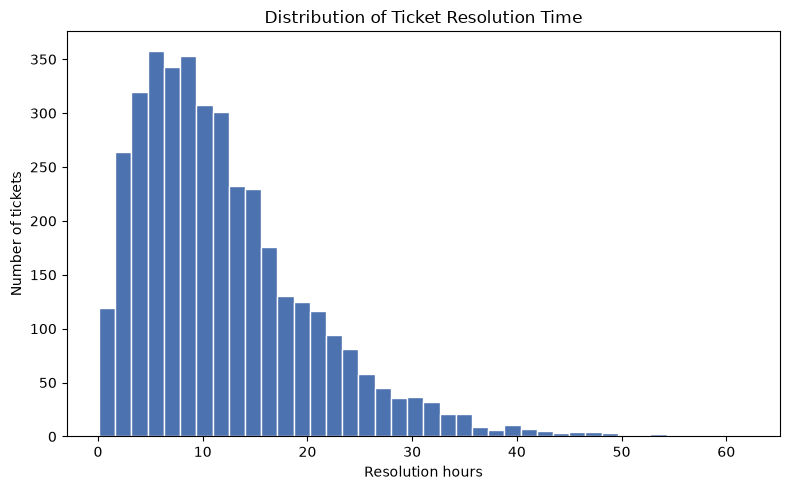

In [24]:
# Distribution: shape/spread of a single continuous variable -> histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clean["resolution_hours"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Ticket Resolution Time")
ax.set_xlabel("Resolution hours")
ax.set_ylabel("Number of tickets")
fig.tight_layout()
fig.savefig("chart_distribution.png", dpi=150)

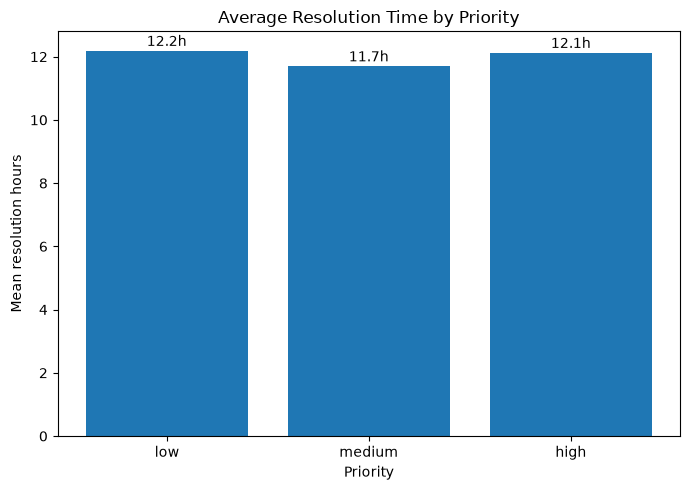

In [25]:
by_priority = clean.groupby("priority")["resolution_hours"].mean().reindex(["low", "medium", "high"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(by_priority.index, by_priority.values)
ax.set_title("Average Resolution Time by Priority")
ax.set_xlabel("Priority")
ax.set_ylabel("Mean resolution hours")
for i, v in enumerate(by_priority.values):
    ax.text(i, v + 0.15, f"{v:.1f}h", ha="center")
fig.tight_layout()
fig.savefig("chart_category_comparison.png", dpi=150)

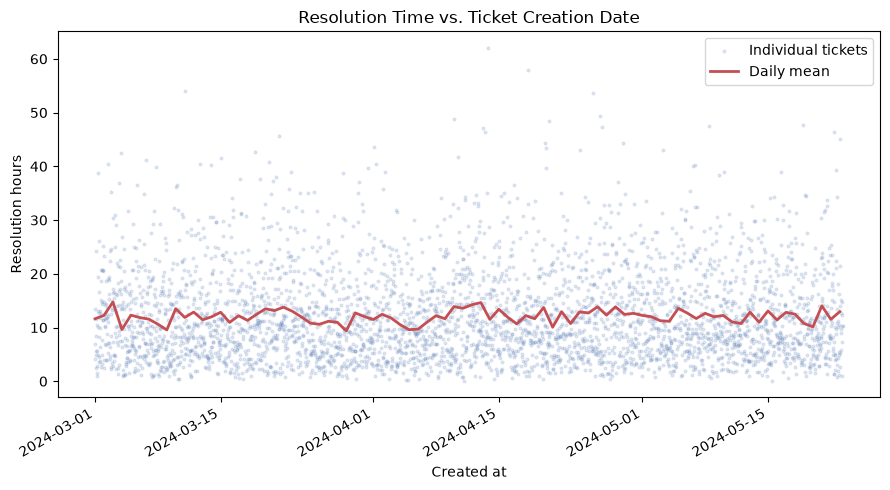

In [26]:
ts = clean.set_index("created_at")["resolution_hours"].sort_index()
daily_mean = ts.resample("D").mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(ts.index, ts.values, s=4, alpha=0.15, color="#4C72B0", label="Individual tickets")
ax.plot(daily_mean.index, daily_mean.values, color="#C44E52", linewidth=2, label="Daily mean")
ax.set_title("Resolution Time vs. Ticket Creation Date")
ax.set_xlabel("Created at")
ax.set_ylabel("Resolution hours")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("chart_relationship.png", dpi=150)

## 4. Findings

1. **Priority barely moves resolution time.** The mean resolution hours for Low, Medium, and High priority tickets are all within about an hour of each other (see `chart_category_comparison.png`) priority as logged doesn't predict how fast a ticket actually gets resolved.
2. **Resolution time is right-skewed, not normal.** `chart_distribution.png` shows a sharp peak around 5–10 hours with a long tail out past 40 hours, a small share of tickets take disproportionately long, so the mean (~10.7h after cleaning) overstates the typical ticket's experience versus the median.
3. **No strong time trend.** The daily mean line in `chart_relationship.png` fluctuates without a clear upward or downward drift across the two-month window, resolution performance looks roughly stable rather than getting better or worse over time.

In [27]:

print(f"Missing agent_id removed: "
      f"{tickets['agent_id'].isna().sum()} rows")

print(f"Negative resolution_hours removed: "
      f"{(tickets['resolution_hours'] < 0).sum()} rows")

print(f"Missing channel values: "
      f"{tickets['channel'].isna().sum()} rows")

print(f"Exact duplicate rows removed: "
      f"{tickets.duplicated().sum()} rows")

print(f"999.0 sentinel values replaced: "
      f"{(tickets['resolution_hours'] == 999.0).sum()} rows")

Missing agent_id removed: 121 rows
Negative resolution_hours removed: 25 rows
Missing channel values: 193 rows
Exact duplicate rows removed: 12 rows
999.0 sentinel values replaced: 15 rows


## 5. Technical Summary

**Dataset:** 4,012 synthetic support tickets (agents 200–259) spanning March–May 2024, with `resolution_hours`, `priority`, and intake `channel` as the main fields of interest.

**Top findings:** Priority level shows little relationship to actual resolution time; resolution time itself is right-skewed with a long tail of slow tickets; and there's no clear time trend across the observed window (see Findings above).

**Limitation:** This dataset is synthetic and randomly generated (`rng.gamma` for resolution time, uniform random assignment of agent/priority/channel), so there is no real causal structure to recover — the "priority doesn't predict resolution time" finding reflects the generator, not a real support operation. Any conclusions here should be read as a demonstration of the EDA workflow, not as evidence about real support-ticket dynamics. Additionally, dropping rows with missing `agent_id` (121) and negative/sentinel `resolution_hours` (40) assumes those rows are equally likely to belong to any priority/channel — if the missingness were systematically tied to one channel or agent, dropping them would bias the cleaned dataset, and this wasn't tested for.